# US Visa Approval Prediction

## About

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on working place and maintain requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

## Problem Statement

OFLC gives job certification applications for employers seeking to bring foreign workers into the United States and grants certifications. As in the last few years the amount of applicants increases and OFLC needs a machine learning model to shortlist visa applicants based on their previous data.

In this project the task is to build a classifcation model with the given data:

- the model will be used to to predict wheater a particular application is approved or not

## Data 

The data set is provded by OFLC and hoseted on [Kaggle](https://www.kaggle.com/datasets/moro23/easyvisa-dataset). It has 25480 records and 12 columns:

- **case_id**: ID of each visa application
- **continent**: Contnent of employee
- **education_of_employee**: Information of education of employee
- **has_job_experience**: Does the employee has any job experience? Y= Yes; N = No
- **requires_job_training**: Does the employee require any job training? Y = Yes; N = No
- **no_of_employees**: Number of employees in the employer's company
- **yr_of_estab**: Year in which the employer's company was established
- **region_of_employment**: Information of foreign worker's intended region of employment in the US.
- **prevailing_wage**: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
- **unit_of_wage**: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
- **full_time_position**: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
- **case_status**: Flag indicating if the Visa was certified or denied

## Evaluation

The project will conclude with the evaluation of the machine learning model selected with a test data set. The output of the predictions can be checked through a confusion matrix, and metrics such as accuracy, precision, recall and F1 score.

## Import Python Modules

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

## Load Dataset

In [2]:
us_visa_data = pd.read_csv("EasyVisa.csv")
print(us_visa_data.head())

  case_id continent education_of_employee has_job_experience  \
0  EZYV01      Asia           High School                  N   
1  EZYV02      Asia              Master's                  Y   
2  EZYV03      Asia            Bachelor's                  N   
3  EZYV04      Asia            Bachelor's                  N   
4  EZYV05    Africa              Master's                  Y   

  requires_job_training  no_of_employees  yr_of_estab region_of_employment  \
0                     N            14513         2007                 West   
1                     N             2412         2002            Northeast   
2                     Y            44444         2008                 West   
3                     N               98         1897                 West   
4                     N             1082         2005                South   

   prevailing_wage unit_of_wage full_time_position case_status  
0         592.2029         Hour                  Y      Denied  
1       83425.65

## Exploratory Data Analysis

### Shape, Summary Satisitics and Data Types

The data types and shape of the data seem to be as expected. One inconsistency in the summay statistics is the very low mimimal value in the `no_of_employees` column (-26). This could be an error during data collection but more investigation is needed to determine how it should be handeled. 

In [3]:
print(f"Shape:\n{us_visa_data.shape}\n")
print(f"Summary statistics:\n{us_visa_data.describe(include="all")}\n")
print(f"Data types:\n{us_visa_data.dtypes}")

Shape:
(25480, 12)

Summary statistics:
       case_id continent education_of_employee has_job_experience  \
count    25480     25480                 25480              25480   
unique   25480         6                     4                  2   
top     EZYV01      Asia            Bachelor's                  Y   
freq         1     16861                 10234              14802   
mean       NaN       NaN                   NaN                NaN   
std        NaN       NaN                   NaN                NaN   
min        NaN       NaN                   NaN                NaN   
25%        NaN       NaN                   NaN                NaN   
50%        NaN       NaN                   NaN                NaN   
75%        NaN       NaN                   NaN                NaN   
max        NaN       NaN                   NaN                NaN   

       requires_job_training  no_of_employees   yr_of_estab  \
count                  25480     25480.000000  25480.000000   
uniqu

### Duplicates and Missing Values

The dataset doesn't contain any missing values or duplicates

In [4]:
print(f"Missing values:\n{us_visa_data.isna().sum()}")

Missing values:
case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


In [5]:
print(f"Duplicate rows: {us_visa_data.duplicated().sum()}")

Duplecate rows: 0


### Count of Numerical and Categorical Features

In [6]:
# Columns that don't have a string data type are numerical
numerical_features = [feature for feature in us_visa_data.columns if us_visa_data[feature].dtype != 'str']

# Columns that are string data type are categorical
categorical_features = [feature for feature in us_visa_data.columns if us_visa_data[feature].dtype == 'str']

print(f"There are {len(numerical_features)} numerical features in the data: {numerical_features}\n")
print(f"There are {len(categorical_features)} categorical features in the data: {categorical_features}")

There are 3 numerical features in the data: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

There are 9 categorical features in the data: ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


`case_id` has unique values for each row and can be dropped since id doesn't provide any useful information. `continent` column is highly biased towards Asia hence all other categories can be combined to form a single category. `unit_of_wage`  seems to be an important column as most records are with yearly contracts.

In [7]:
# Proportions of categories in each categorical feature
for feature in categorical_features:
    print(us_visa_data[feature].value_counts(normalize=True) * 100)
    print('---------------------------')

case_id
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
EZYV05       0.003925
               ...   
EZYV25476    0.003925
EZYV25477    0.003925
EZYV25478    0.003925
EZYV25479    0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
---------------------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
---------------------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
---------------------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
---------------------------
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
---------------------------
region_of_employment
Northeast    2

### Univariate Analysis

#### Numerical Features

In [8]:
# Investigating to find a pattern that might expalain what negative number of employees means
print(us_visa_data[us_visa_data["no_of_employees"] < 0])

         case_id      continent education_of_employee has_job_experience  \
245      EZYV246         Europe              Master's                  N   
378      EZYV379           Asia            Bachelor's                  N   
832      EZYV833  South America              Master's                  Y   
2918    EZYV2919           Asia              Master's                  Y   
6439    EZYV6440           Asia            Bachelor's                  N   
6634    EZYV6635           Asia            Bachelor's                  Y   
7224    EZYV7225         Europe             Doctorate                  N   
7281    EZYV7282           Asia           High School                  N   
7318    EZYV7319           Asia            Bachelor's                  Y   
7761    EZYV7762           Asia              Master's                  N   
9872    EZYV9873         Europe              Master's                  Y   
11493  EZYV11494           Asia           High School                  Y   
13471  EZYV1

In [9]:
# If the number of records with negative number of employees is small, those records can be dropped
print(us_visa_data[us_visa_data["no_of_employees"] < 0].value_counts().sum())

33


In [10]:
# Getting the indices of the records with negative number of employees
negative_no_employees = us_visa_data[us_visa_data["no_of_employees"] < 0 ].index
negative_no_employees

Index([  245,   378,   832,  2918,  6439,  6634,  7224,  7281,  7318,  7761,
        9872, 11493, 13471, 14022, 14146, 14726, 15600, 15859, 16157, 16883,
       17006, 17655, 17844, 17983, 20815, 20984, 21255, 21760, 21944, 22084,
       22388, 23186, 23476],
      dtype='int64')

In [11]:
# The problematic records are only 33 so they can be safely dropped
us_visa_data = us_visa_data.drop(negative_no_employees)
us_visa_data.shape

(25447, 12)

The `no_of_employees` feature has a long right skew and what seems to be an exponentially decreaseing distribution where the most of the values are small and are concentrated on the left side of the graph.

The `yr_of_estab` (year of establishment) is a discreate feature. Most of the companies in the dataset are relatively new.

The `prevailing_wage` feature has a right skew and what seems to be a log-normal ditribution. This is normal for any kind of salary data since wages depend on multiple factors such as education, work experience, industry, bonuses and etc.

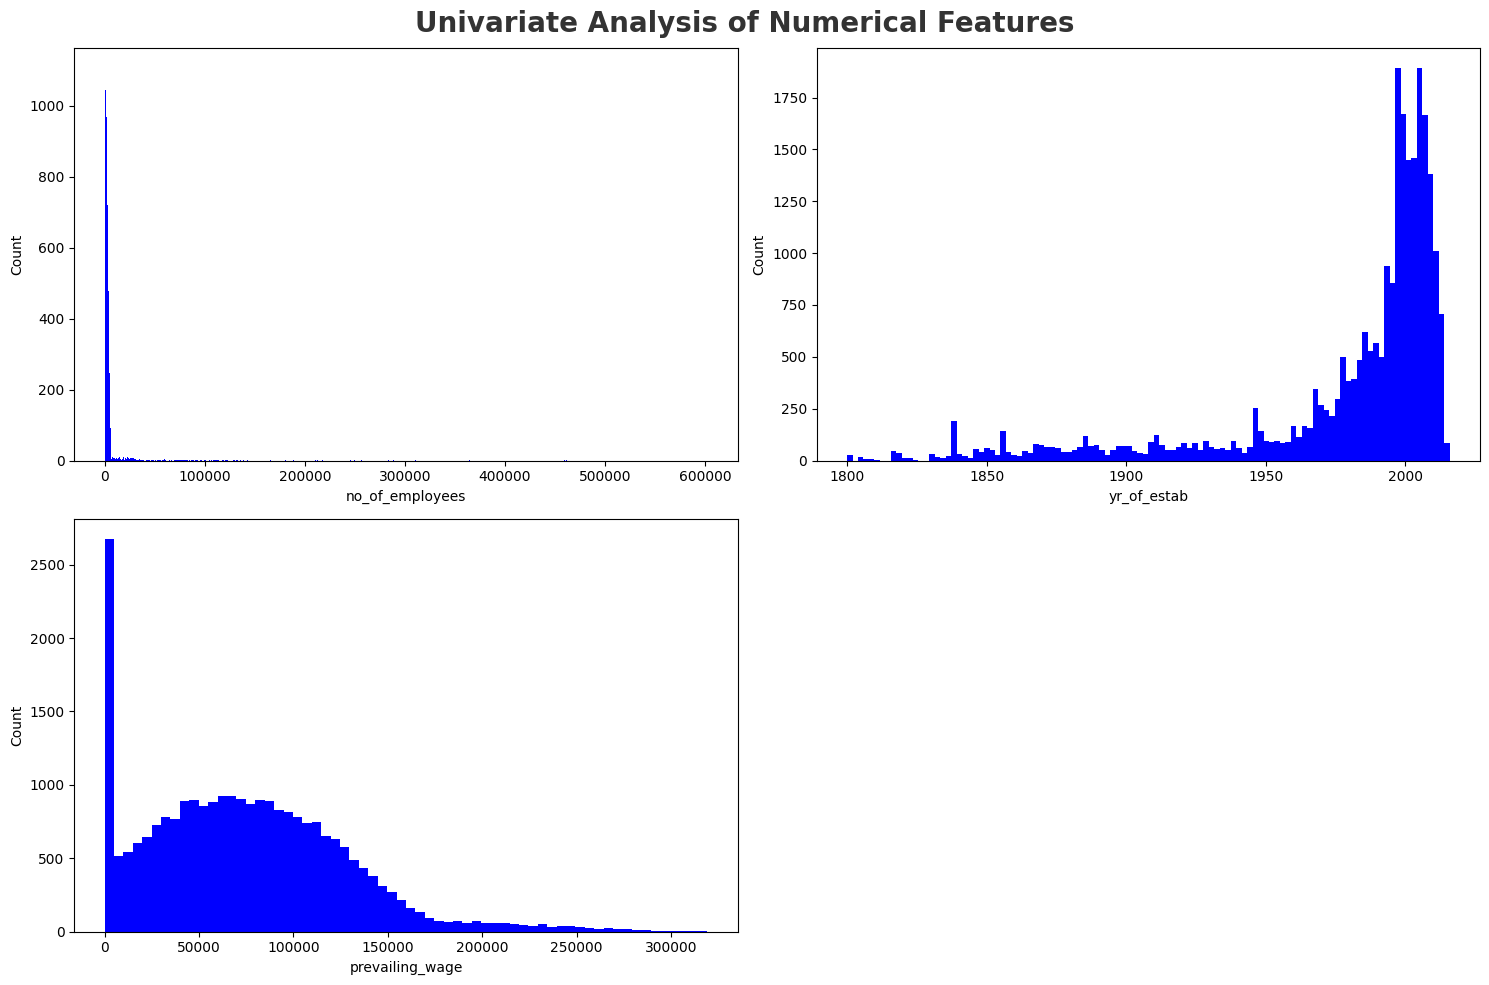

In [12]:
plt.figure(figsize=(15, 10))
plt.suptitle("Univariate Analysis of Numerical Features", fontsize=20, fontweight="bold", alpha=0.8)

for i in range(0, len(numerical_features)):
    plt.subplot(2, 2, i+1)
    plt.hist(us_visa_data[numerical_features[i]], color="blue", bins="fd")
    plt.xlabel(numerical_features[i])
    plt.ylabel("Count")
    plt.tight_layout()

### Categorical Features

The `requires_job_training`, `unit_of_wage`, `full_time_position` and `continents` coulmns have a signle category dominating. All other features are relatively balanced

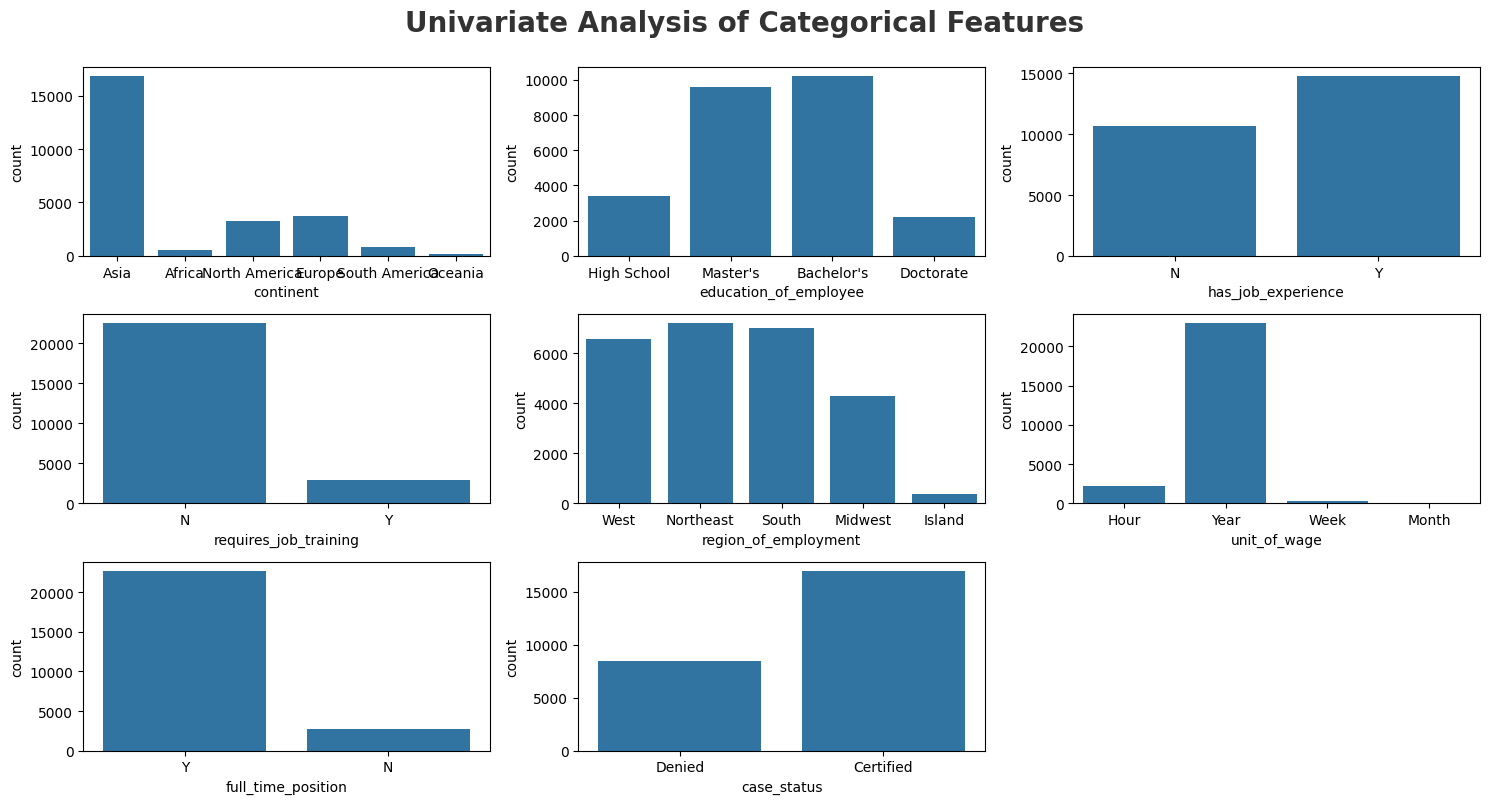

In [13]:
categorical_features.remove('case_id')
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(categorical_features)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=us_visa_data[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()

### Multivariate Analysis 

Multivariate analysis refers to the process of analyzing multiple variables the interactions between them

#### Correlations Between Numerical Features 

All numerical features are very weakly correlated with the target column and with each other. There migth be realtionships between the features and the target column but not linear relationships

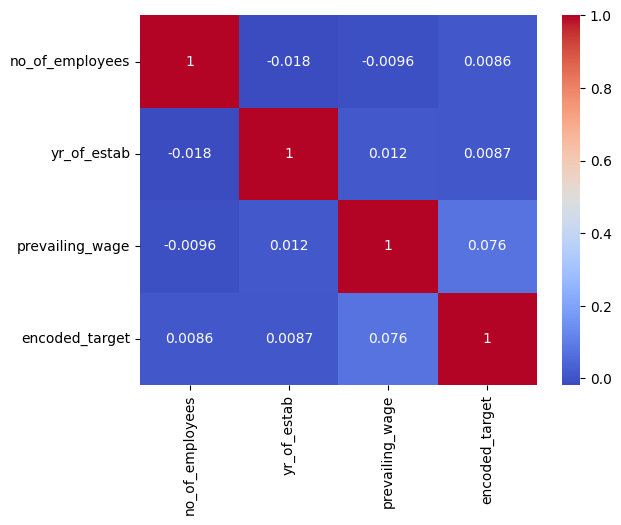

In [14]:
# Encoding the target column just to plot the correlation heatmap
us_visa_data["encoded_target"] = us_visa_data["case_status"].apply(lambda row: 0 if row == "Denied" else 1)

corr_matrix = us_visa_data.corr(numeric_only=True)

# Plotting a correlation heatmap to check which nunerical features are correlated with the target. 
# This could also help to check for features correlated with each other (multycolinearity) which causes overfitting
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.show()


#### Correlations Between Cateogorical Features

One way to test the relationship between two categorical variables is with a chi-squared test. The test determines if the relationship between two categorical variables is statistically significant. 

- Null hypothesis ($ H_0 $): The feature is independent of the target column (No correlation)
- Alternative hypthesis ($ H_1 $): The feature and the target column are not independent (Correlated)
- $ \alpha $ = 0.05

Only `requires_job_training` fails to reject the null hypothesis and all other features seem to be correleted with the target column 

In [15]:
alpha = 0.05

chi2_test = [] # Tests assuming H0 is True
for feature in categorical_features:
    # if the returned p-value is less than alpha, the feature and the target column are correlated
    if chi2_contingency(pd.crosstab(us_visa_data['case_status'], us_visa_data[feature]))[1] < alpha:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
        
result = pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Test Result']
result

,Column,Test Result
0,continent,Reject Null Hypothesis
1,education_of_employee,Reject Null Hypothesis
2,has_job_experience,Reject Null Hypothesis
3,requires_job_training,Fail to Reject Null Hypothesis
4,region_of_employment,Reject Null Hypothesis
5,unit_of_wage,Reject Null Hypothesis
6,full_time_position,Reject Null Hypothesis
7,case_status,Reject Null Hypothesis


All of the numerical features require careful preprocessing and scaling because of the skewed distributions.

C:\Users\ilian\AppData\Local\Temp\ipykernel_16044\2314839278.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=us_visa_data, x='case_status', y=col,  palette=clr1, ax=ax[i,0])
C:\Users\ilian\AppData\Local\Temp\ipykernel_16044\2314839278.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=us_visa_data, x='case_status', y=col,  palette=clr1, ax=ax[i,0])
C:\Users\ilian\AppData\Local\Temp\ipykernel_16044\2314839278.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=us_visa_data, x='case_status', y=col,  palette=clr1, ax=ax[i,0]

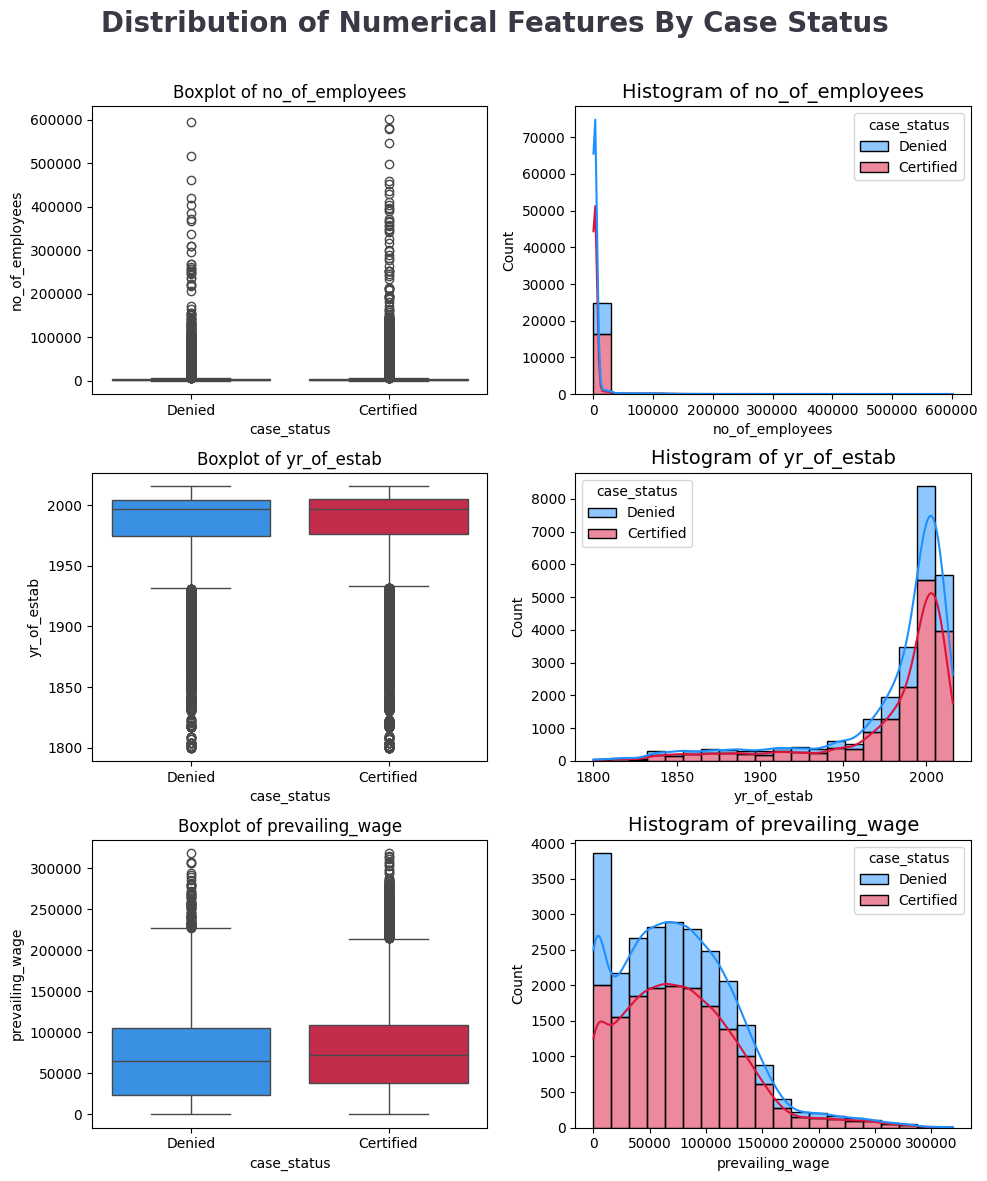

In [16]:
clr1 = ['#1E90FF', '#DC143C']
fig, ax = plt.subplots(3, 2, figsize=(10,12))
fig.suptitle('Distribution of Numerical Features By Case Status', color='#3C3744',
             fontsize=20, fontweight='bold', ha='center')
for i, col in enumerate(numerical_features):   
    sns.boxplot(data=us_visa_data, x='case_status', y=col,  palette=clr1, ax=ax[i,0])
    ax[i,0].set_title(f'Boxplot of {col}', fontsize=12)
    sns.histplot(data=us_visa_data, x=col, hue='case_status', bins=20, kde=True, 
                 multiple='stack', palette=clr1, ax=ax[i,1])
    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.90)
# plt.savefig('images/multivariate_num.png')

#### Target Column Distribution

Here the ceritifed label dominates over the denied label. This is a typical example of class imbalance however here the more interesting (positive) class is better represented than the other.

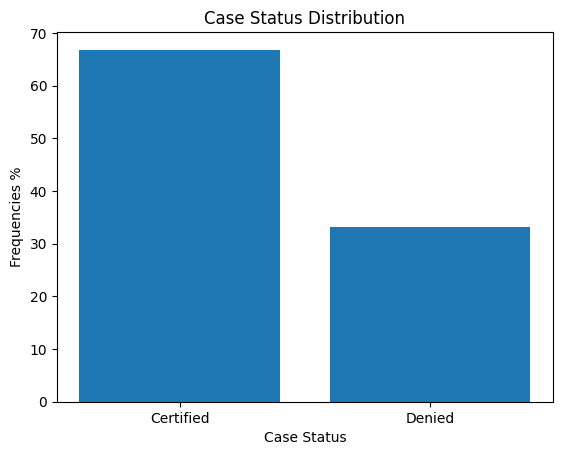

In [17]:
percentages = us_visa_data["case_status"].value_counts(normalize=True) * 100

plt.bar(percentages.index, percentages.values)
plt.title("Case Status Distribution")
plt.xlabel("Case Status")
plt.ylabel("Frequencies %")
plt.show()

#### Does applicant continent has any impact on visa approval status?

- As per the Chart the most number of applicants are from `Asia`.
- 43% of Certified applications are from `Asia`.
- This is followed by Europe with 11% of Certified applications.
- Highest chance of getting certified if you are from `Europe` and followed by `Africa`

In [18]:
# Group data by continent and their count of case_status
us_visa_data.groupby('continent')['case_status'].value_counts(normalize=True).to_frame() * 100

proportion
continent     case_status            
Africa        Certified     72.000000
              Denied        28.000000
Asia          Certified     65.326603
              Denied        34.673397
Europe        Certified     79.232627
              Denied        20.767373
North America Certified     61.971402
              Denied        38.028598
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.814336
              Denied        42.185664

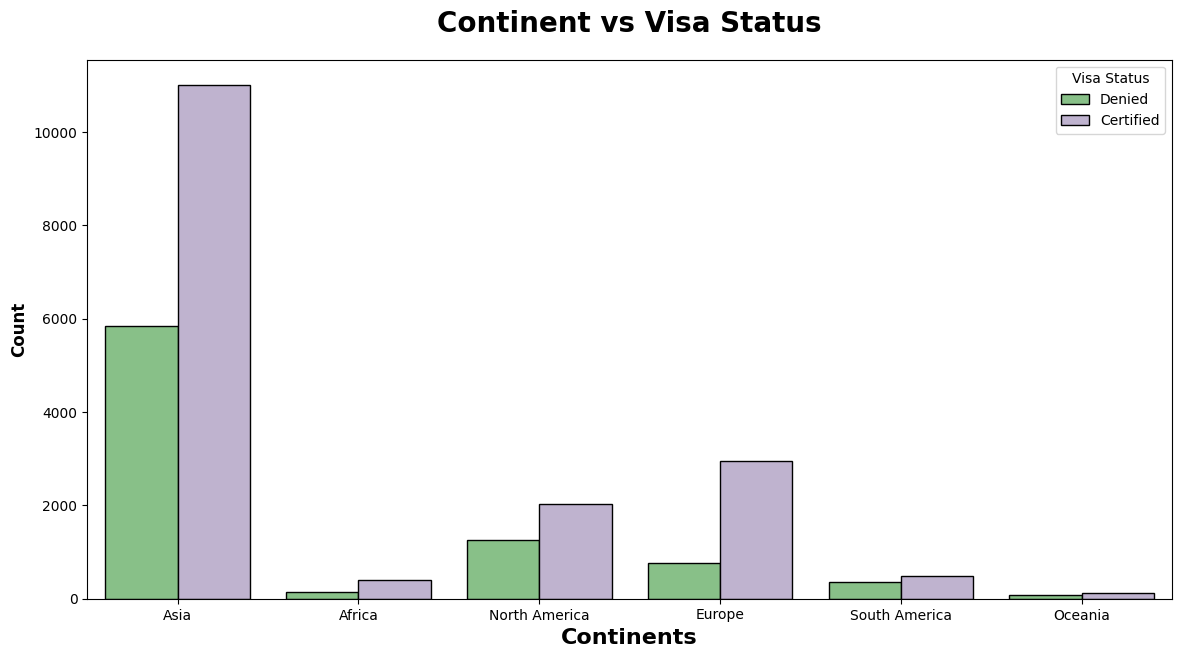

In [19]:
plt.subplots(figsize=(14,7))
sns.countplot(x="continent",hue="case_status", data=us_visa_data, ec = "black",palette="Accent")
plt.title("Continent vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Continents", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

In [20]:
us_visa_data_copy = us_visa_data.copy()

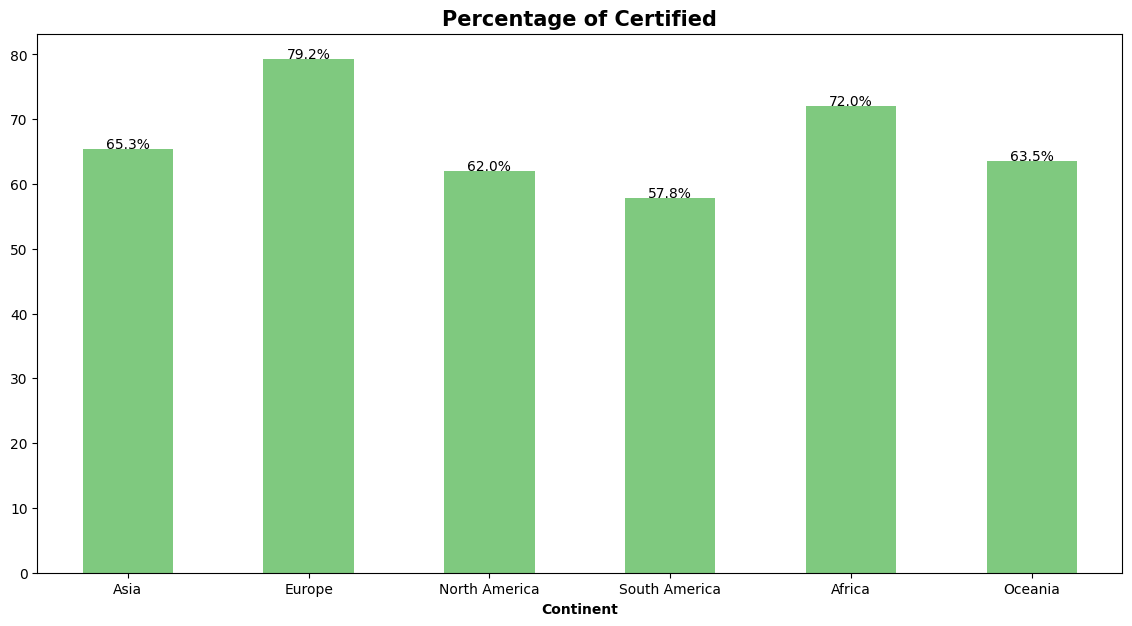

In [21]:
plt.figure(figsize=[14,7])

(100 * us_visa_data_copy[us_visa_data_copy["case_status"].isin(['Certified'])]['continent'].value_counts() / us_visa_data_copy['continent'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified" , fontsize = 15, fontweight ='bold'  )
order1 = (100 * us_visa_data_copy[us_visa_data_copy["case_status"].isin(['Certified'])]['continent'].value_counts() / us_visa_data_copy['continent'].value_counts())
for n in range(len(order1)):
    count = order1.values[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n, count+0.1, strt, ha='center')

plt.xlabel('Continent' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

#### Does applicant education have any impact on visa approval status?

Education of the applicant has high impact on visa application status. `Doctorate` and `Master's` graduates have a higher chance of getting certified than the others. 

In [22]:
#group data by Education and their count of case_status
us_visa_data.groupby('education_of_employee')['case_status'].value_counts(normalize=True).to_frame() * 100

proportion
education_of_employee case_status            
Bachelor's            Certified     62.250489
                      Denied        37.749511
Doctorate             Certified     87.254454
                      Denied        12.745546
High School           Denied        65.925059
                      Certified     34.074941
Master's              Certified     78.621908
                      Denied        21.378092

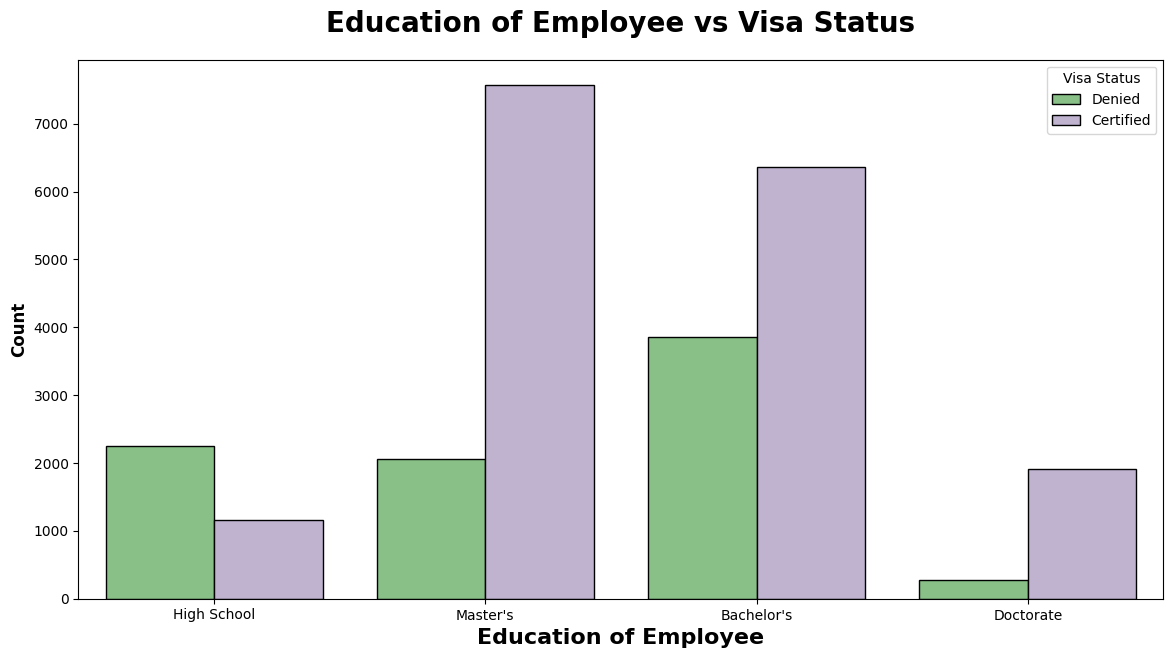

In [23]:
plt.subplots(figsize=(14,7))
sns.countplot(x="education_of_employee",hue="case_status", data=us_visa_data, ec = "black",palette="Accent")
plt.title("Education of Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Education of Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

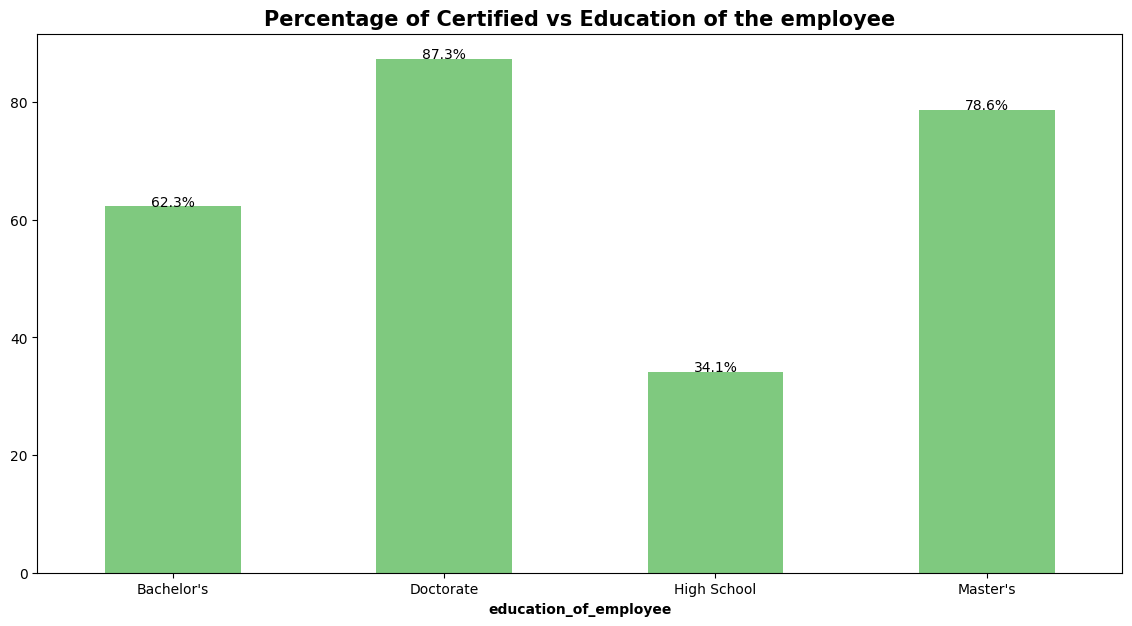

In [24]:
plt.figure(figsize=[14, 7])

(100*us_visa_data_copy[us_visa_data_copy["case_status"].isin(['Certified'])]['education_of_employee'].value_counts()/us_visa_data_copy['education_of_employee'].value_counts()).plot(
    kind='bar', stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs Education of the employee" , fontsize = 15, fontweight ='bold'  )

order1 = (100*us_visa_data_copy[us_visa_data_copy["case_status"].isin(['Certified'])]['education_of_employee'].value_counts()/us_visa_data_copy['education_of_employee'].value_counts())
for n in range(order1.shape[0]):
    count = order1.values[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n, count+0.1, strt, ha='center')

plt.xlabel('education_of_employee' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

#### Does applicant's previous work experiance have any impact on visa approval status?

- Work experience has impact on visa application status
- 74.5 % of the applicants with previous work experience have been certified 25.5% have been denied
- 56% of the applicants without previous work experience have been certified and 43% denied
- There is a slight edge for the applicants with work experience as expected. But the difference is not huge

In [25]:
us_visa_data.groupby("has_job_experience")["case_status"].value_counts(normalize=True).to_frame() * 100

proportion
has_job_experience case_status            
N                  Certified     56.148579
                   Denied        43.851421
Y                  Certified     74.496145
                   Denied        25.503855

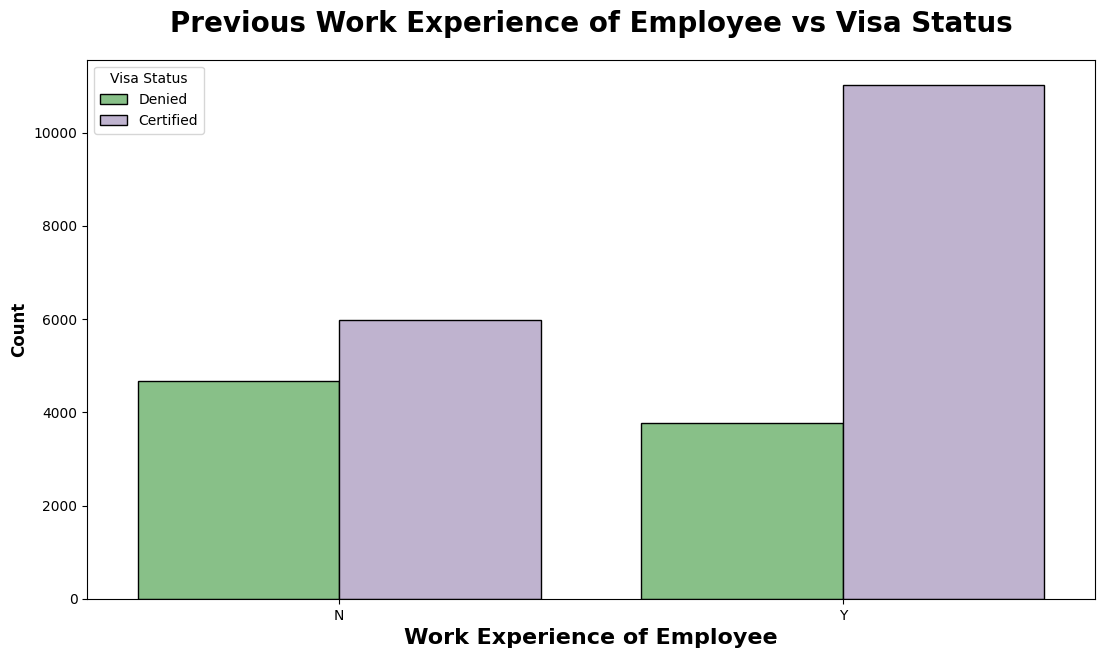

In [26]:
plt.subplots(figsize=(13,7))
sns.countplot(x="has_job_experience",hue="case_status", data=us_visa_data, ec= "black",palette="Accent")
plt.title("Previous Work Experience of Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Work Experience of Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

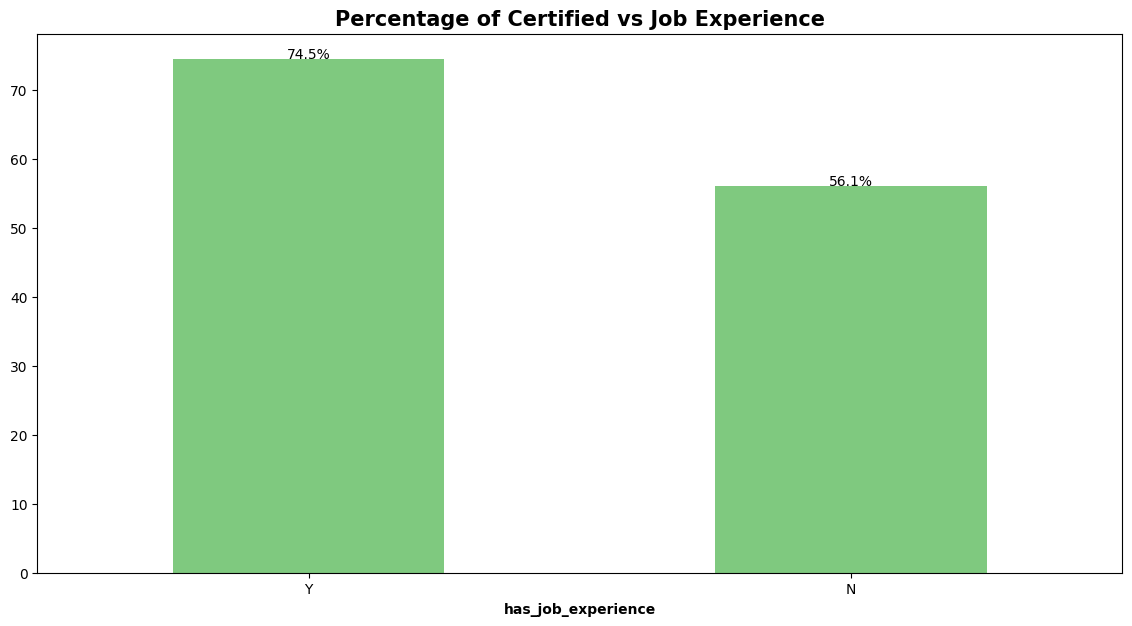

In [27]:
plt.figure(figsize=[14, 7])

(100 * us_visa_data_copy[us_visa_data_copy["case_status"].isin(['Certified'])]['has_job_experience'].value_counts() / us_visa_data_copy['has_job_experience'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs Job Experience" , fontsize = 15, fontweight ='bold'  )
order1 = (100 * us_visa_data_copy[us_visa_data_copy["case_status"].isin(['Certified'])]['has_job_experience'].value_counts() / us_visa_data_copy['has_job_experience'].value_counts())
for n in range(order1.shape[0]):
    count = order1.values[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n, count+0.1, strt, ha='center')

plt.xlabel('has_job_experience' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

#### If the employee requires job training, does it impact visa approval status?

`requires_job_training` has no impact on visa approval status. 88% of applicants don't require job training. 63% of people who don't require job training got certified. 67% of the applicants who require job training got certified. The Chi-Squared test performed before also confirms that  

In [32]:
us_visa_data.groupby("requires_job_training")["case_status"].value_counts(normalize=True).to_frame() * 100

proportion
requires_job_training case_status            
N                     Certified     66.672593
                      Denied        33.327407
Y                     Certified     67.853510
                      Denied        32.146490

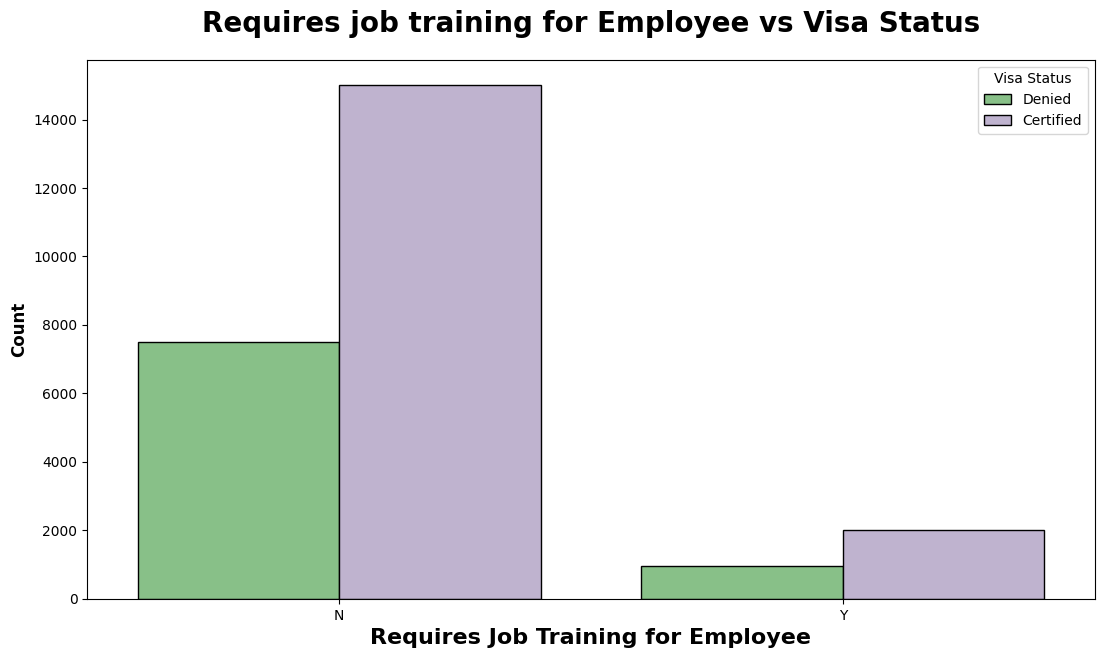

In [33]:
plt.subplots(figsize=(13,7))
sns.countplot(x="requires_job_training",hue="case_status", data=us_visa_data, ec= "black",palette="Accent")
plt.title("Requires job training for Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

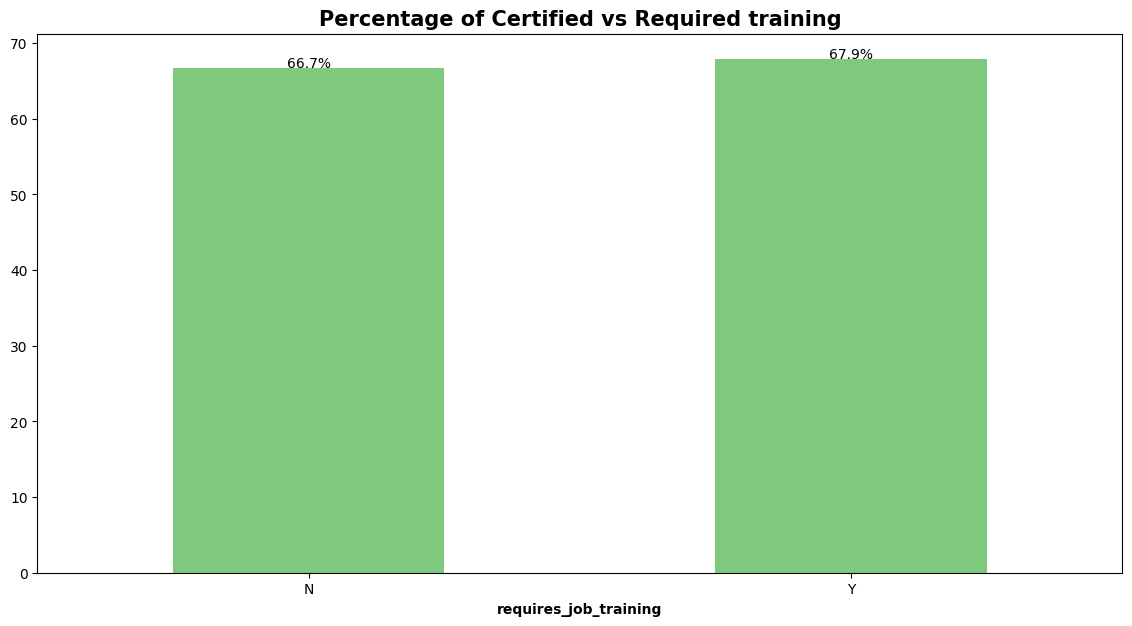

In [34]:
plt.figure(figsize=[14,7])

(100 * us_visa_data_copy[us_visa_data_copy["case_status"].isin(['Certified'])]['requires_job_training'].value_counts() / us_visa_data_copy['requires_job_training'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs Required training" , fontsize = 15, fontweight ='bold'  )
order1 = (100 * us_visa_data_copy[us_visa_data_copy["case_status"].isin(['Certified'])]['requires_job_training'].value_counts() / us_visa_data_copy['requires_job_training'].value_counts())
for n in range(order1.shape[0]):
    count = order1.values[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('requires_job_training' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()